## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.dpi"] = 120

BASE_DIR  = os.path.abspath("..")
DATA_DIR  = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

DATA_PATH = os.path.join(DATA_DIR, "executions.csv")

## Load Raw Data

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape}  ({df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns)")
display(df_raw.head(3))

Shape: (9400, 84)  (9,400 rows × 84 columns)


,program_id,execution_id,suggestion_id,source_path,source_hash,line_number,pattern,severity,severity_ordinal,detector_family,...,count_unused_vars,count_dead_code,count_constant_folding,count_early_return,count_loop_invariant,count_string_concat_loop,count_nested_loops,count_hot_loop,count_repeated_computation,count_expensive_calls
0,0001_print_sum_of_two_numbers.py,0001_print_sum_of_two_numbers.py@f967f8f418f828bb,0001_print_sum_of_two_numbers.py@f967f8f418f82...,/Users/stha_manik/Projects/OptiLang/optilang/o...,f967f8f418f828bb,70,unused_vars,low,1,static,...,1,0,2,1,0,0,0,0,0,0
1,0001_print_sum_of_two_numbers.py,0001_print_sum_of_two_numbers.py@f967f8f418f828bb,0001_print_sum_of_two_numbers.py@f967f8f418f82...,/Users/stha_manik/Projects/OptiLang/optilang/o...,f967f8f418f828bb,23,early_return,low,1,static,...,1,0,2,1,0,0,0,0,0,0
2,0001_print_sum_of_two_numbers.py,0001_print_sum_of_two_numbers.py@f967f8f418f828bb,0001_print_sum_of_two_numbers.py@f967f8f418f82...,/Users/stha_manik/Projects/OptiLang/optilang/o...,f967f8f418f828bb,9,constant_folding,low,1,static,...,1,0,2,1,0,0,0,0,0,0


In [3]:
df_raw.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 9400 entries, 0 to 9399
Data columns (total 84 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   program_id                   9400 non-null   str    
 1   execution_id                 9400 non-null   str    
 2   suggestion_id                9400 non-null   str    
 3   source_path                  9400 non-null   str    
 4   source_hash                  9400 non-null   str    
 5   line_number                  9400 non-null   int64  
 6   pattern                      9400 non-null   str    
 7   severity                     9400 non-null   str    
 8   severity_ordinal             9400 non-null   int64  
 9   detector_family              9400 non-null   str    
 10  score_dimension              9400 non-null   str    
 11  impact_score                 9400 non-null   float64
 12  token_count                  9400 non-null   int64  
 13  ast_node_count               

## Null Audit

In [4]:
null_counts = df_raw.isnull().sum()
null_pct    = (null_counts / len(df_raw) * 100).round(2)
null_df     = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
null_df     = null_df[null_df.null_count > 0].sort_values("null_count", ascending=False)

if null_df.empty:
    print("No nulls found in the dataset.")
else:
    display(null_df)
    print(f"\nTotal null cells: {null_counts.sum():,}")

,null_count,null_pct
nearest_function_name,6600,70.21



Total null cells: 6,600


## Feature Drop Decisions

#### Zero-Variance Columns

Columns that carry a single value across all 9,400 rows contribute zero information.

In [5]:
# Expected zero-variance cols per Feature Decision Sheet
ZERO_VARIANCE_DROPS = ["grade", "uses_lists", "uses_dicts",
                       "uses_recursion", "uses_exceptions", "inside_try"]

print("=== Empirical zero-variance verification ===")
for col in ZERO_VARIANCE_DROPS:
    uniq = df_raw[col].unique()
    status = "CONFIRMED" if len(uniq) == 1 else f"✗ has {len(uniq)} values — REVIEW"
    print(f"  {col:<30} unique={list(uniq)}  {status}")

=== Empirical zero-variance verification ===
  grade                          unique=['Excellent']  CONFIRMED
  uses_lists                     unique=[np.True_]  CONFIRMED
  uses_dicts                     unique=[np.True_]  CONFIRMED
  uses_recursion                 unique=[np.True_]  CONFIRMED
  uses_exceptions                unique=[np.True_]  CONFIRMED
  inside_try                     unique=[np.False_]  CONFIRMED


#### Exact Duplicates / Near-Redundant Columns

In [6]:
REDUNDANT_DROPS = ["is_inside_loop", "total_time_ms_at_line",
                   "min_time_ms_at_line", "max_time_ms_at_line"]

# is_inside_loop vs inside_loop
overlap = (df_raw["is_inside_loop"] == df_raw["inside_loop"]).mean()
print(f"is_inside_loop == inside_loop: {overlap:.4f}  {'DUPLICATE' if overlap == 1.0 else 'NOT IDENTICAL'}")

# total_time vs derived product
derived = df_raw["execution_count_at_line"] * df_raw["avg_time_ms_at_line"]
corr_total = df_raw["total_time_ms_at_line"].corr(derived)
print(f"total_time_ms_at_line corr with exec_countxavg_time: {corr_total:.4f}")

# min/max vs avg
corr_min = df_raw["min_time_ms_at_line"].corr(df_raw["avg_time_ms_at_line"])
corr_max = df_raw["max_time_ms_at_line"].corr(df_raw["avg_time_ms_at_line"])
print(f"min_time_ms corr with avg_time_ms: {corr_min:.4f}")
print(f"max_time_ms corr with avg_time_ms: {corr_max:.4f}")

is_inside_loop == inside_loop: 1.0000  DUPLICATE
total_time_ms_at_line corr with exec_countxavg_time: 0.9661
min_time_ms corr with avg_time_ms: 0.9812
max_time_ms corr with avg_time_ms: 0.9272


#### Target Leakage

In [7]:
LEAKAGE_DROPS = ["score", "correctness_score", "efficiency_complexity_score",
                 "quality_score", "maintainability_score"]
print("Leakage columns (excluded from clustering and classification features):")
for col in LEAKAGE_DROPS:
    exists = col in df_raw.columns
    print(f"  {col:<35} in dataset: {exists}")

display(df_raw[["impact_score"]].describe().T)

Leakage columns (excluded from clustering and classification features):
  score                               in dataset: True
  correctness_score                   in dataset: True
  efficiency_complexity_score         in dataset: True
  quality_score                       in dataset: True
  maintainability_score               in dataset: True


,count,mean,std,min,25%,50%,75%,max
impact_score,9400.0,3.510638,2.967156,2.0,2.0,2.0,3.0,18.0


#### Program-Level Noise

In [8]:
PROGRAM_LEVEL_DROPS = [
    "token_count", "ast_node_count", "source_lines", "execution_time_ms",
    "total_lines_executed", "unique_lines_profiled", "peak_memory_bytes",
    "total_suggestions", "suggestion_density", "complexity_confidence",
    "function_count", "loop_count", "if_count", "try_count",
    "assignment_count", "call_count", "binary_op_count",
    "high_severity_count", "medium_severity_count", "low_severity_count",
    "static_suggestion_count", "hybrid_suggestion_count", "dynamic_suggestion_count",
    "count_unused_vars", "count_dead_code", "count_constant_folding",
    "count_early_return", "count_loop_invariant", "count_string_concat_loop",
    "count_nested_loops", "count_hot_loop", "count_repeated_computation",
    "count_expensive_calls",
]

present = [c for c in PROGRAM_LEVEL_DROPS if c in df_raw.columns]
print(f"Program-level columns to drop: {len(present)} of {len(PROGRAM_LEVEL_DROPS)} present")

sample_prog_cols = [c for c in ["token_count", "source_lines", "total_suggestions"] if c in df_raw.columns]
if sample_prog_cols:
    print("\nSample program-level columns — note they repeat per program:")
    display(df_raw[sample_prog_cols].describe().T)

Program-level columns to drop: 33 of 33 present

Sample program-level columns — note they repeat per program:


,count,mean,std,min,25%,50%,75%,max
token_count,9400.0,450.510638,14.120109,425.0,440.0,456.0,461.0,472.0
source_lines,9400.0,76.446809,2.060976,73.0,75.0,77.0,78.0,79.0
total_suggestions,9400.0,4.914894,1.107669,4.0,4.0,4.0,6.0,7.0


#### Identifiers & Non-Generalizable Columns

In [9]:
IDENTIFIER_DROPS = ["line_number", "nearest_function_name",
                    "same_line_suggestion_count", "co_occurring_patterns"]

# Verify near-zero variance of same_line_suggestion_count
slsc = df_raw["same_line_suggestion_count"].value_counts(normalize=True)
print("same_line_suggestion_count distribution:")
print(slsc.to_string())
print(f"\n{slsc.iloc[0]*100:.1f}% of rows have value=1 (near-zero variance → drop)")

# Verify nearest_function_name — only 4 dataset-specific values
print("\nnearest_function_name unique values:")
print(df_raw["nearest_function_name"].value_counts(dropna=False))

same_line_suggestion_count distribution:
same_line_suggestion_count
1    0.957447
2    0.042553

95.7% of rows have value=1 (near-zero variance → drop)

nearest_function_name unique values:
nearest_function_name
NaN                 6600
inner_adjust        2000
choose_path          400
normalize_amount     200
slow_mix             200
Name: count, dtype: int64


#### Circular / Derived Columns

In [10]:
CIRCULAR_DROPS = ["detector_family", "score_dimension", "impact_score",
                  "complexity_class", "severity", "severity_ordinal", "pattern"]

print("detector_family unique:",   df_raw["detector_family"].unique())
print("score_dimension unique:",   df_raw["score_dimension"].unique())
print("complexity_class unique:",  df_raw["complexity_class"].unique())
print("severity unique:",          df_raw["severity"].unique())
print("severity_ordinal unique:", df_raw["severity_ordinal"].unique())
print("\npattern value counts:")
display(df_raw["pattern"].value_counts().to_frame())

detector_family unique: <StringArray>
['static', 'hybrid', 'dynamic']
Length: 3, dtype: str
score_dimension unique: <StringArray>
['maintainability', 'quality', 'efficiency']
Length: 3, dtype: str
complexity_class unique: <StringArray>
['O(n^k)', 'O(n²)', 'O(n)']
Length: 3, dtype: str
severity unique: <StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str
severity_ordinal unique: [1 2 3]

pattern value counts:


,count
pattern,
constant_folding,4800
early_return,2400
unused_vars,600
hot_loop,400
dead_code,200
loop_invariant,200
string_concat_loop,200
nested_loops,200
repeated_computation,200


#### Drop Summary

In [11]:
ALL_DROPS = list(set(
    ZERO_VARIANCE_DROPS
    + REDUNDANT_DROPS
    + LEAKAGE_DROPS
    + PROGRAM_LEVEL_DROPS
    + IDENTIFIER_DROPS
    + CIRCULAR_DROPS
))

drops_present = [c for c in ALL_DROPS if c in df_raw.columns]
drops_missing = [c for c in ALL_DROPS if c not in df_raw.columns]

print(f"Total columns in raw data : {df_raw.shape[1]}")
print(f"Columns scheduled to drop  : {len(drops_present)}")
print(f"Remaining after drop       : {df_raw.shape[1] - len(drops_present)}")
if drops_missing:
    print(f"\nColumns not found in dataset (already absent or renamed): {drops_missing}")

Total columns in raw data : 84
Columns scheduled to drop  : 59
Remaining after drop       : 25


## Apply Drops → Working DataFrame

In [12]:
df = df_raw.drop(columns=drops_present, errors="ignore").copy()
print(f"Shape after drops: {df.shape}")
display(df.dtypes.to_frame("dtype").T)

Shape after drops: (9400, 25)


,program_id,execution_id,suggestion_id,source_path,source_hash,node_type_at_line,inside_function,inside_loop,inside_branch,loop_depth,...,memory_vars_at_line,memory_bytes_at_line,line_dominance,line_execution_rank,line_time_rank,function_call_count,function_total_time_ms,function_avg_time_ms,max_recursion_depth,complexity_ordinal
dtype,str,str,str,str,str,str,bool,bool,bool,int64,...,int64,int64,float64,int64,int64,int64,float64,float64,int64,int64


## Final Feature Matrix: Keep Columns

In [13]:
# Structural context 
STRUCT_COLS = [
    "loop_depth", "branch_depth", "function_depth",
    "inside_function", "inside_loop", "inside_branch", "max_recursion_depth",
    "complexity_ordinal", "relative_line_position",
]

# Dynamic / runtime
DYNAMIC_COLS = [
    "execution_count_at_line", "avg_time_ms_at_line", "line_dominance",
    "line_execution_rank", "line_time_rank", "memory_bytes_at_line",
]

# Function-level dynamic (3)
FUNC_COLS = [
    "function_call_count", "function_total_time_ms", "function_avg_time_ms",
]

# Categorical to one-hot (1 → 4 binary)
CAT_COLS = ["node_type_at_line"]

FEATURE_COLS = STRUCT_COLS + DYNAMIC_COLS + FUNC_COLS + CAT_COLS

missing_feats = [c for c in FEATURE_COLS if c not in df.columns]
print(f"Feature columns defined  : {len(FEATURE_COLS)}")
print(f"Missing from working df  : {missing_feats or 'None'}")
print(f"Final feature count (pre-OHE): {len(FEATURE_COLS)} → post-OHE: ~{len(FEATURE_COLS) - 1 + 4}")

Feature columns defined  : 19
Missing from working df  : None
Final feature count (pre-OHE): 19 → post-OHE: ~22


## Descriptive Statistics — Retained Features

#### Structural Features

In [14]:
display(df[STRUCT_COLS].describe().T.round(4))

,count,mean,std,min,25%,50%,75%,max
loop_depth,9400.0,0.4043,0.5324,0.0000,0.0000,0.0000,1.0000,2.000
branch_depth,9400.0,0.4894,0.4999,0.0000,0.0000,0.0000,1.0000,1.000
function_depth,9400.0,0.5106,0.8219,0.0000,0.0000,0.0000,1.0000,2.000
max_recursion_depth,9400.0,0.2128,0.4093,0.0000,0.0000,0.0000,0.0000,1.000
complexity_ordinal,9400.0,4.6170,0.7870,3.0000,5.0000,5.0000,5.0000,5.000
relative_line_position,9400.0,0.6003,0.3446,0.1139,0.2911,0.7949,0.9211,0.962


**Key observations:**
- `complexity_ordinal` has only two values — 3 and 5 (1,800 vs 7,600 rows).
- `branch_depth` is binary (0/1); `max_recursion_depth` is binary (0/1).
- `relative_line_position` is bimodal — most suggestions cluster near the start (0.29) or end (0.92) of functions.

#### Dynamic / Runtime Features

In [15]:
display(df[DYNAMIC_COLS].describe().T.round(6))

print("\nZero-proportion in sparse runtime columns:")
for c in ["execution_count_at_line", "avg_time_ms_at_line", "memory_bytes_at_line"]:
    z = (df[c] == 0).mean()
    print(f"  {c:<35}: {z*100:.1f}% zeros")

,count,mean,std,min,25%,50%,75%,max
execution_count_at_line,9400.0,2.659574,4.904782,0.0,0.0,1.000000,5.000000,30.000000
avg_time_ms_at_line,9400.0,0.001376,0.001534,0.0,0.0,0.001000,0.002000,0.013000
line_dominance,9400.0,0.028533,0.049074,0.0,0.0,0.008264,0.041322,0.247934
line_execution_rank,9400.0,25.617021,18.789354,0.0,6.0,19.000000,46.000000,53.000000
line_time_rank,9400.0,21.413085,20.039457,0.0,4.0,9.000000,46.000000,53.000000
memory_bytes_at_line,9400.0,3944.713723,738.058134,0.0,4137.0,4270.500000,4298.000000,4431.000000



Zero-proportion in sparse runtime columns:
  execution_count_at_line            : 36.2% zeros
  avg_time_ms_at_line                : 36.2% zeros
  memory_bytes_at_line               : 2.1% zeros


**Key observations:**
- `execution_count_at_line` and `avg_time_ms_at_line` have **36.2% zeros** — static suggestions that were never executed. These will use `log1p` transform before scaling.
- `execution_count_at_line` takes only 6 discrete values: {0, 1, 5, 8, 13, 30}.
- `memory_bytes_at_line` is right-skewed with a narrow range (2% zeros).

#### Function-Level Dynamic Features

In [16]:
display(df[FUNC_COLS].describe().T.round(6))

print("\nSkewness (before log1p):")
for c in FUNC_COLS:
    print(f"  {c:<35}: {df[c].skew():.2f}")

,count,mean,std,min,25%,50%,75%,max
function_call_count,9400.0,0.531915,1.748662,0.0,0.0,0.0,1.000,12.000
function_total_time_ms,9400.0,3.179463,21.537775,0.0,0.0,0.0,0.016,180.697
function_avg_time_ms,9400.0,0.269195,1.794205,0.0,0.0,0.0,0.016,15.058



Skewness (before log1p):
  function_call_count                : 5.99
  function_total_time_ms             : 6.64
  function_avg_time_ms               : 6.64


**Key observations:**
- All three function-level columns are **heavily right-skewed** (skew > 5.9) — dominated by zero values for static suggestions. `log1p` transform is mandatory before StandardScaler.

#### Categorical Feature — `node_type_at_line`

In [17]:
node_counts = df["node_type_at_line"].value_counts()
node_pct    = (node_counts / len(df) * 100).round(1)
display(pd.DataFrame({"count": node_counts, "pct": node_pct}))
print(f"\nCardinality: {df['node_type_at_line'].nunique()} — will produce 4 one-hot columns")

,count,pct
node_type_at_line,,
AssignmentNode,4200,44.7
NumberNode,3000,31.9
NullNode,2000,21.3
AugmentedAssignmentNode,200,2.1



Cardinality: 4 — will produce 4 one-hot columns


## Distribution Analysis

#### Pattern Frequency

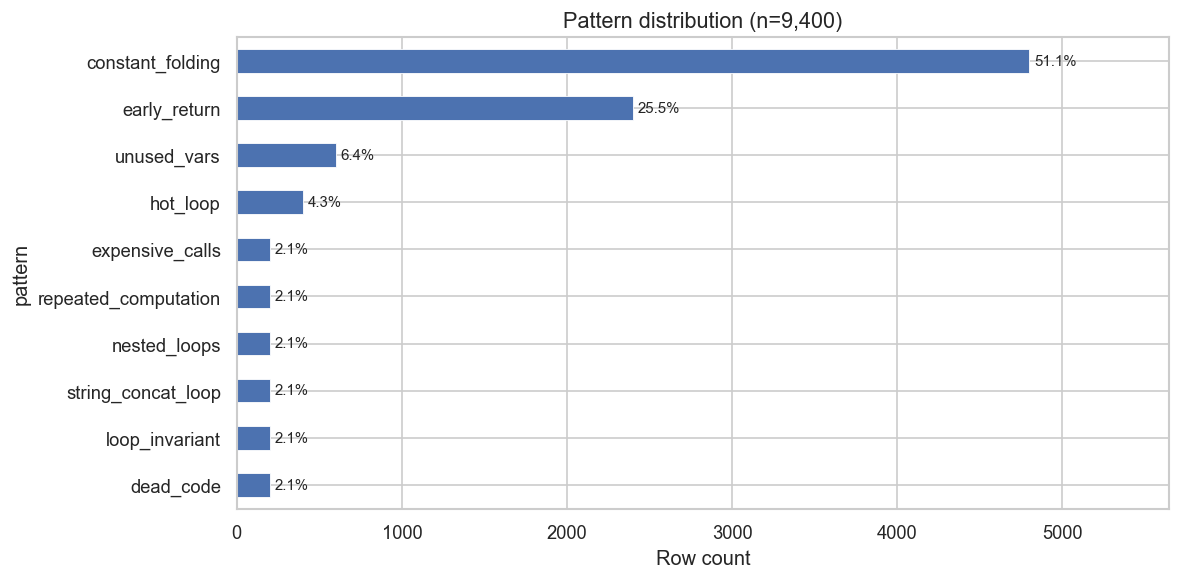

In [18]:
pat_counts = df_raw["pattern"].value_counts()
pat_pct    = (pat_counts / len(df_raw) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = pat_counts.sort_values(ascending=True).plot(
    kind="barh", ax=ax, color="#4C72B0", edgecolor="white", linewidth=0.5
)
for bar, pct in zip(ax.patches, pat_pct.sort_values(ascending=True)):
    ax.text(
        bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
        f"{pct}%", va="center", fontsize=9
    )
ax.set_xlabel("Row count")
ax.set_title("Pattern distribution (n=9,400)", fontsize=13)
ax.set_xlim(0, ax.get_xlim()[1] * 1.12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "pattern_frequency.png"), dpi=150)
plt.show()

#### Severity Distribution

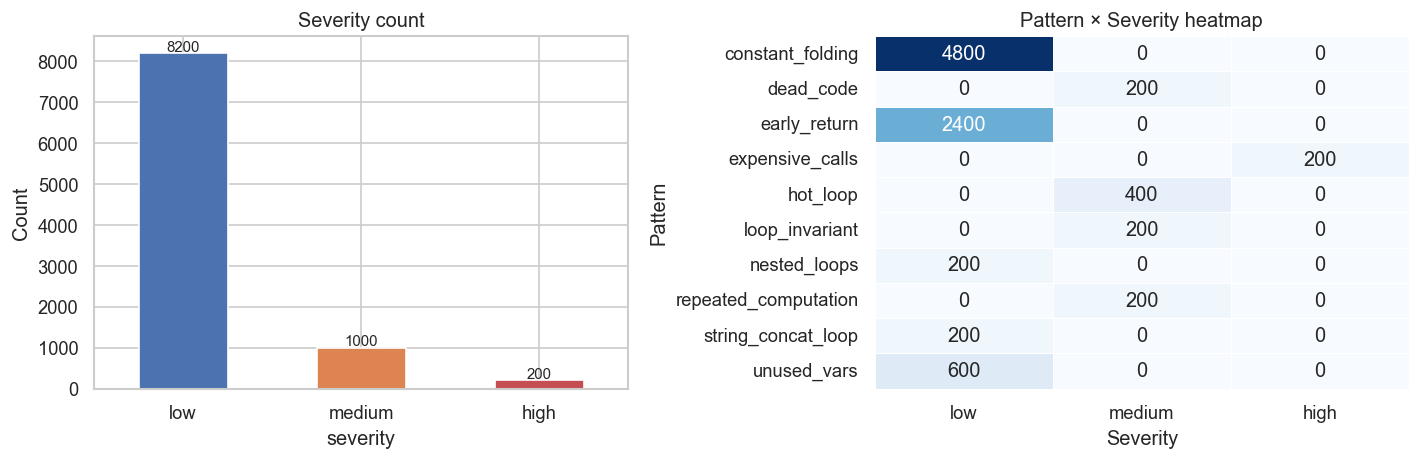


Observation: severity maps perfectly onto pattern — confirming severity is circular for clustering.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Severity count
sev_counts = df_raw["severity"].value_counts().reindex(["low", "medium", "high"])
colors = ["#4C72B0", "#DD8452", "#C44E52"]
sev_counts.plot(kind="bar", ax=axes[0], color=colors, edgecolor="white", rot=0)
axes[0].set_title("Severity count", fontsize=12)
axes[0].set_ylabel("Count")
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
        f"{bar.get_height():.0f}", ha="center", fontsize=9
    )

# Pattern × Severity heatmap
cross = pd.crosstab(df_raw["pattern"], df_raw["severity"])[["low", "medium", "high"]]
sns.heatmap(cross, ax=axes[1], annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, linecolor="white", cbar=False)
axes[1].set_title("Pattern × Severity heatmap", fontsize=12)
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("Pattern")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "severity_distribution.png"), dpi=150)
plt.show()

print("\nObservation: severity maps perfectly onto pattern — confirming severity is circular for clustering.")

#### Detector Family × Pattern

In [20]:
cross_det = pd.crosstab(df_raw["pattern"], df_raw["detector_family"])
display(cross_det)
print("\n→ Each row has exactly one non-zero column: 1:1 mapping confirmed. Drop detector_family from features.")

detector_family,dynamic,hybrid,static
pattern,,,
constant_folding,0,0,4800
dead_code,0,0,200
early_return,0,0,2400
expensive_calls,200,0,0
hot_loop,400,0,0
loop_invariant,0,200,0
nested_loops,0,200,0
repeated_computation,200,0,0
string_concat_loop,0,200,0



→ Each row has exactly one non-zero column: 1:1 mapping confirmed. Drop detector_family from features.


#### Runtime Feature Distributions (log scale)

Showing pre- and post-`log1p` to motivate the transform.

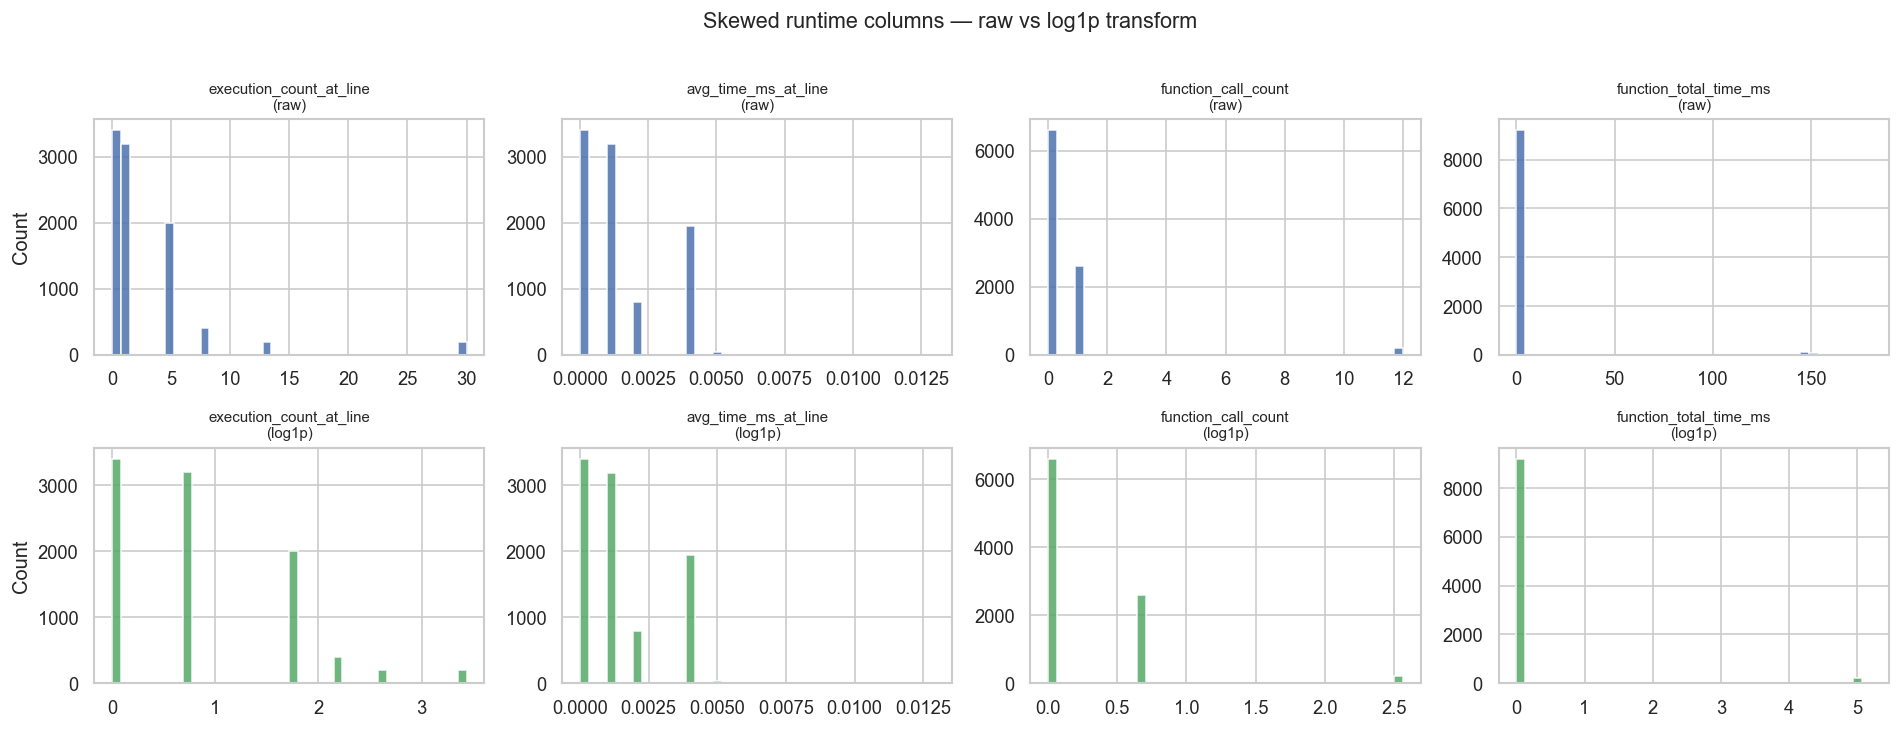

In [21]:
log1p_cols = [
    "execution_count_at_line", "avg_time_ms_at_line",
    "function_call_count", "function_total_time_ms",
]

fig, axes = plt.subplots(2, len(log1p_cols), figsize=(16, 6))
for j, col in enumerate(log1p_cols):
    # Raw
    axes[0, j].hist(df[col], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[0, j].set_title(f"{col}\n(raw)", fontsize=9)
    axes[0, j].set_ylabel("Count" if j == 0 else "")
    # log1p
    axes[1, j].hist(np.log1p(df[col]), bins=40, color="#55A868", edgecolor="white", alpha=0.85)
    axes[1, j].set_title(f"{col}\n(log1p)", fontsize=9)
    axes[1, j].set_ylabel("Count" if j == 0 else "")

fig.suptitle("Skewed runtime columns — raw vs log1p transform", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "runtime_log1p_transforms.png"), dpi=150, bbox_inches="tight")
plt.show()

#### Structural Discrete Features

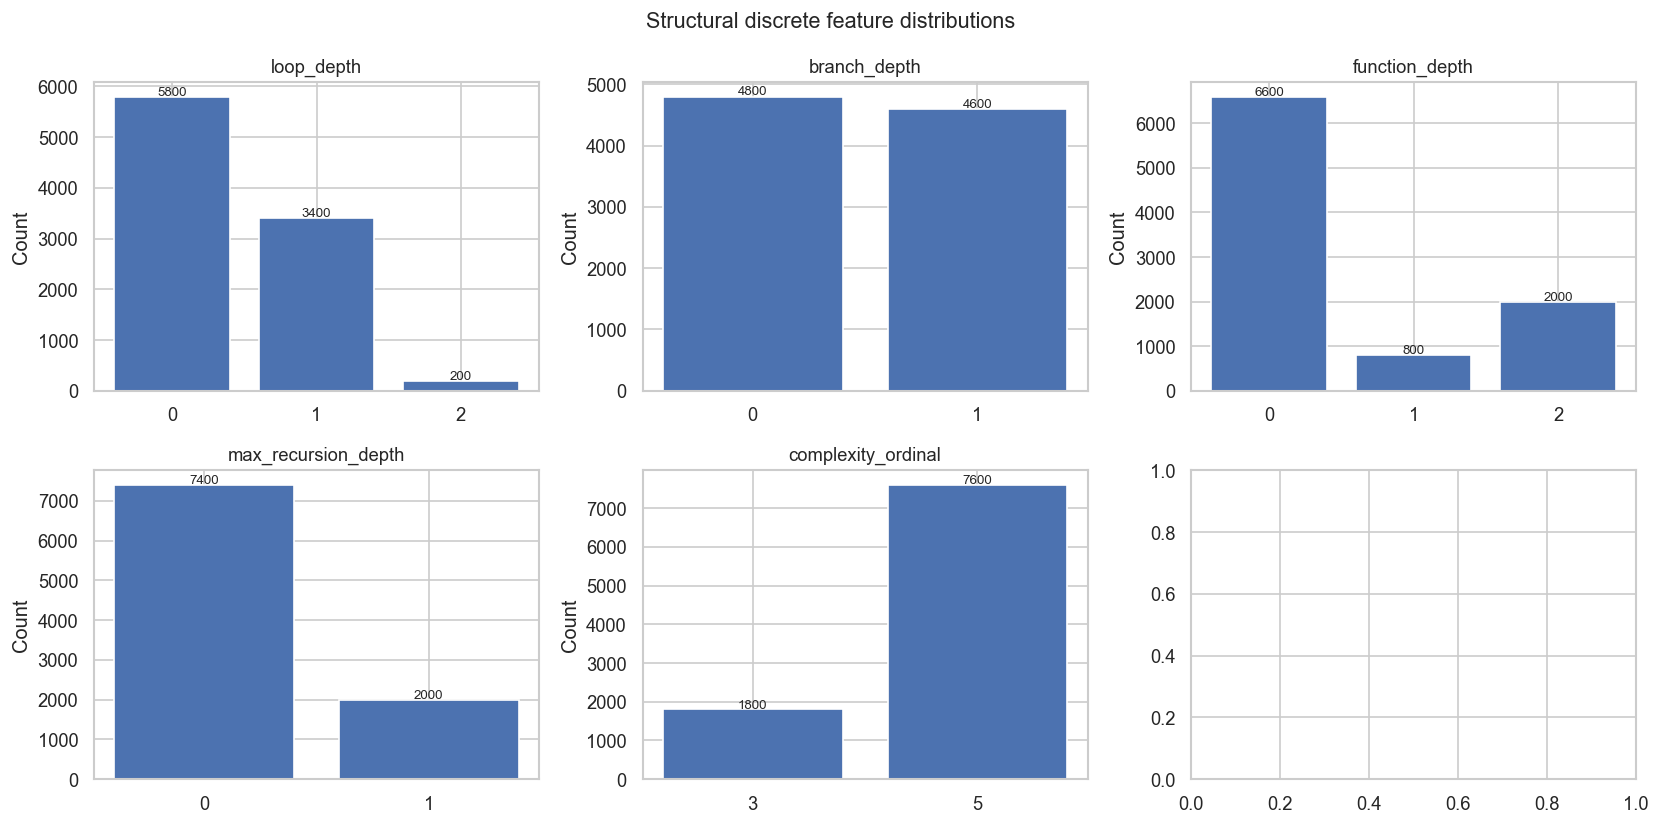

In [22]:
discrete_cols = ["loop_depth", "branch_depth", "function_depth",
                 "max_recursion_depth", "complexity_ordinal"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(discrete_cols):
    vc = df[col].value_counts().sort_index()
    axes[i].bar(vc.index.astype(str), vc.values, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Count")
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{bar.get_height():.0f}", ha="center", fontsize=8
        )

plt.suptitle("Structural discrete feature distributions", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "structural_discrete_distributions.png"), dpi=150)
plt.show()

#### `impact_score`

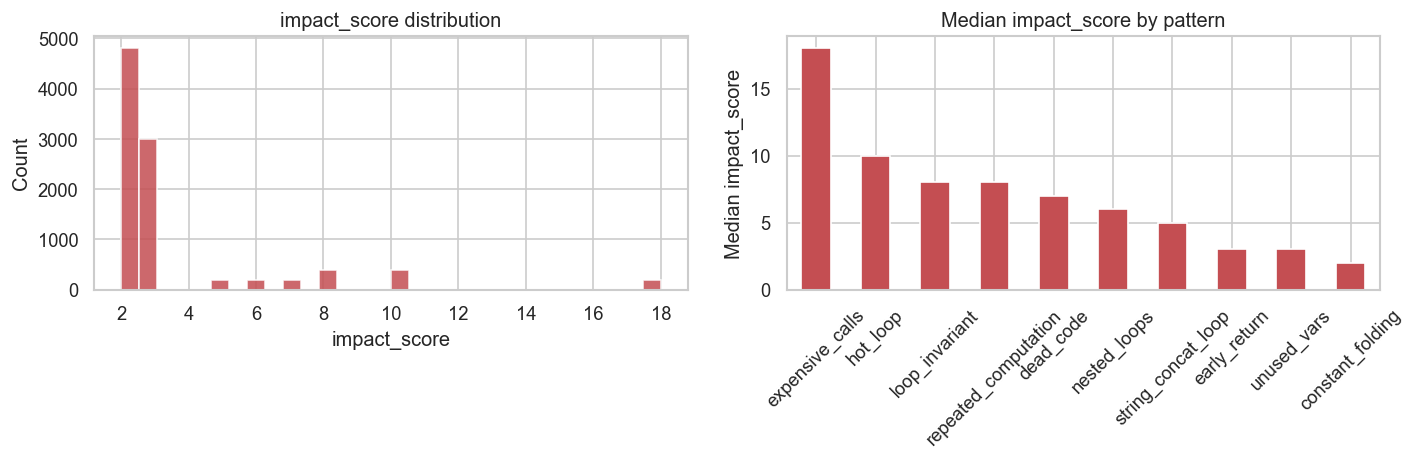

impact_score range: [2.0, 18.0]
Mean: 3.51, Median: 2.00, Std: 2.97


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw["impact_score"], bins=30, color="#C44E52", edgecolor="white", alpha=0.85)
axes[0].set_title("impact_score distribution", fontsize=12)
axes[0].set_xlabel("impact_score")
axes[0].set_ylabel("Count")

impact_by_pattern = df_raw.groupby("pattern")["impact_score"].median().sort_values(ascending=False)
impact_by_pattern.plot(kind="bar", ax=axes[1], color="#C44E52", edgecolor="white", rot=45)
axes[1].set_title("Median impact_score by pattern", fontsize=12)
axes[1].set_ylabel("Median impact_score")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "impact_score_distribution.png"), dpi=150)
plt.show()

print(f"impact_score range: [{df_raw.impact_score.min()}, {df_raw.impact_score.max()}]")
print(f"Mean: {df_raw.impact_score.mean():.2f}, Median: {df_raw.impact_score.median():.2f}, Std: {df_raw.impact_score.std():.2f}")

### Correlation Analysis — Retained Numeric Features

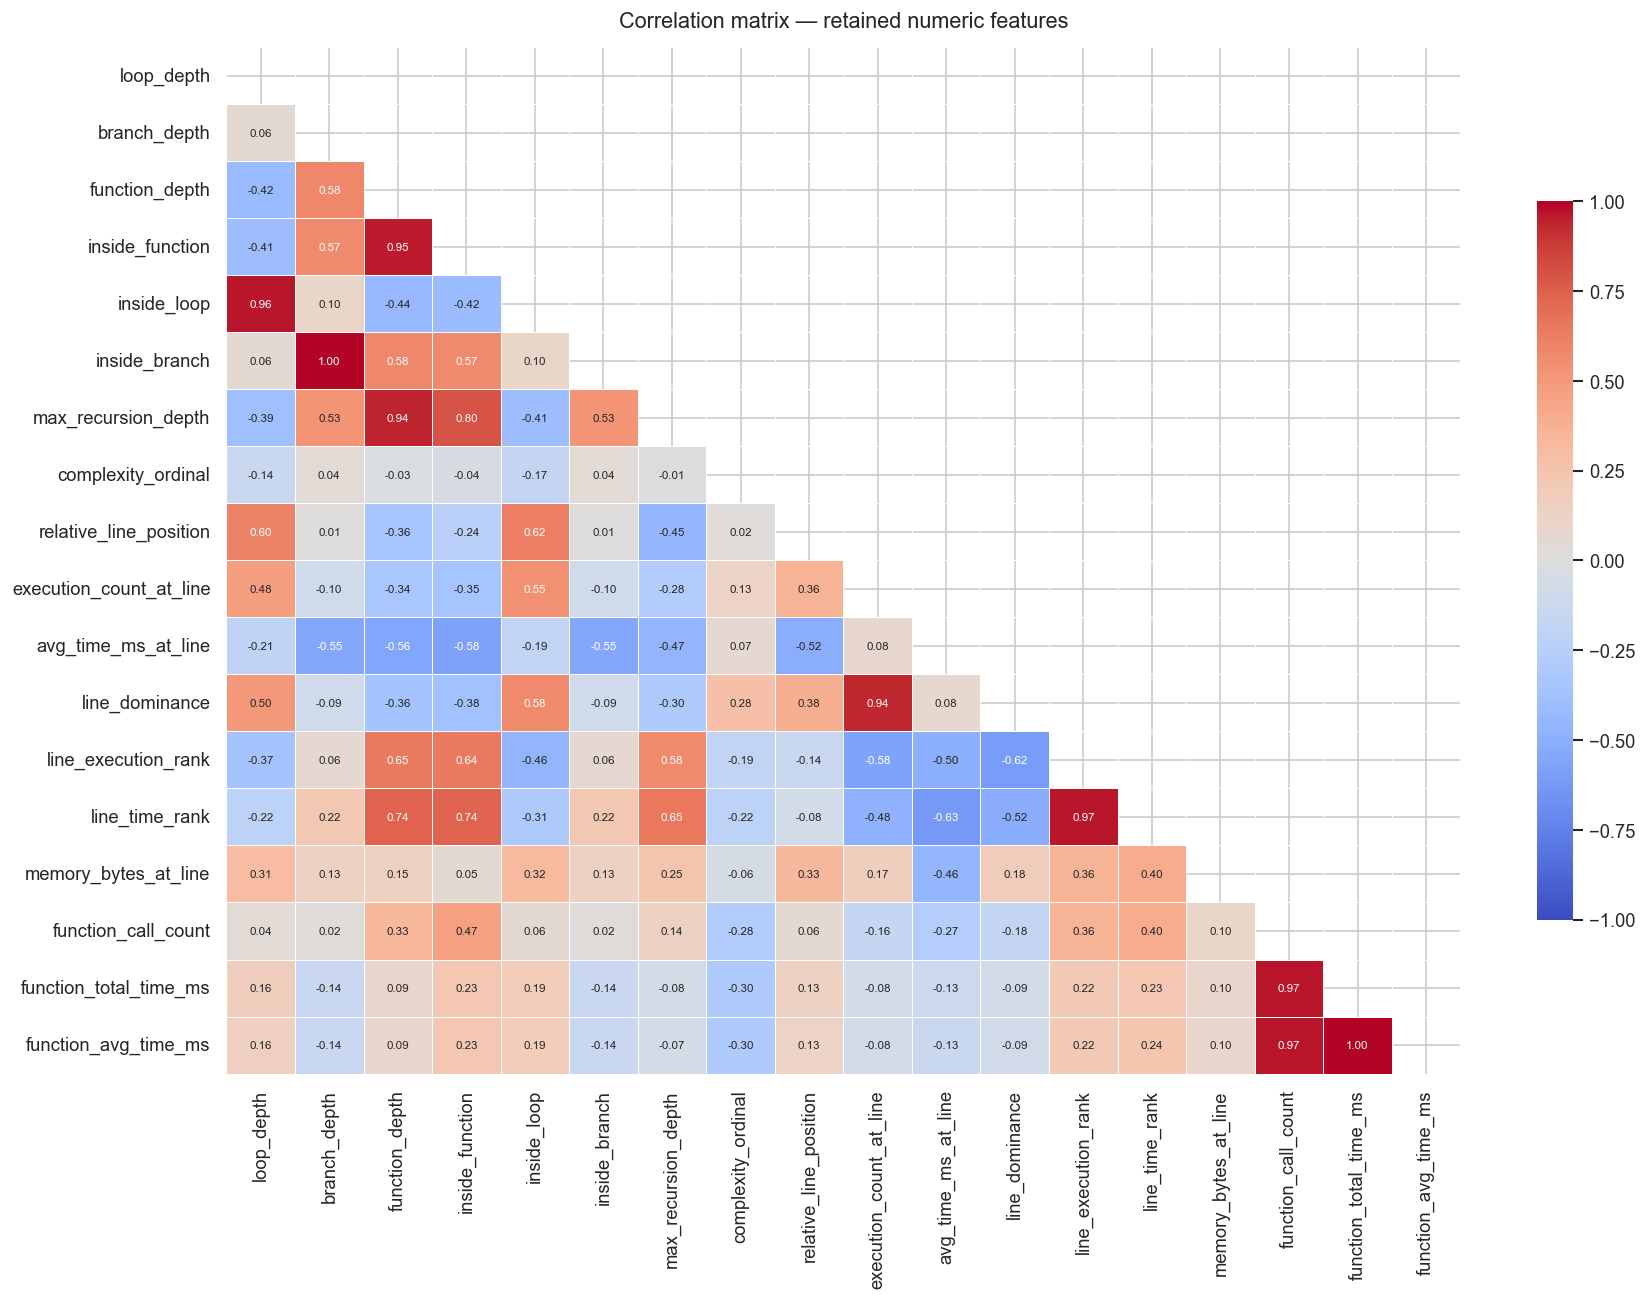

High-correlation pairs (|r| ≥ 0.70) among retained features:


,col_a,col_b,corr
91,inside_branch,branch_depth,1.000000
322,function_avg_time_ms,function_total_time_ms,0.999992
321,function_avg_time_ms,function_call_count,0.967852
303,function_total_time_ms,function_call_count,0.966892
246,line_time_rank,line_execution_rank,0.965647
72,inside_loop,loop_depth,0.963894
56,inside_function,function_depth,0.953937
110,max_recursion_depth,function_depth,0.942134
207,line_dominance,execution_count_at_line,0.935171
111,max_recursion_depth,inside_function,0.798164


In [24]:
numeric_keep = [c for c in STRUCT_COLS + DYNAMIC_COLS + FUNC_COLS if c in df.columns]
corr = df[numeric_keep].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(15, 11))
sns.heatmap(
    corr, mask=mask, ax=ax,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="white",
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Correlation matrix — retained numeric features", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "correlation_heatmap_keep_cols.png"), dpi=150)
plt.show()

# Flag high correlations
high_corr = (
    corr.where(mask == False).abs()
    .stack()
    .reset_index()
    .rename(columns={0: "corr", "level_0": "col_a", "level_1": "col_b"})
    .query("corr >= 0.7 and col_a != col_b")
    .sort_values("corr", ascending=False)
)
if not high_corr.empty:
    print("High-correlation pairs (|r| ≥ 0.70) among retained features:")
    display(high_corr)
else:
    print("No high-correlation pairs found among retained features — feature set is clean.")

### Preprocessing 

In [25]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings

df_feat = df[FEATURE_COLS].copy()
df_feat["was_executed"] = (df_feat["execution_count_at_line"] > 0).astype(int)

# 1. log1p on sparse/skewed runtime columns
LOG1P_COLS = [
    "execution_count_at_line", "avg_time_ms_at_line",
    "function_call_count", "function_total_time_ms", "function_avg_time_ms",
]
for c in LOG1P_COLS:
    df_feat[c] = np.log1p(df_feat[c])

# 2. One-hot encode node_type_at_line
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
joblib.dump(ohe, os.path.join(MODELS_DIR, "ohe_node_type.joblib"))
print("Saved: ohe_node_type.joblib")
                    
node_encoded = ohe.fit_transform(df_feat[["node_type_at_line"]])
node_cols    = [f"node_{c}" for c in ohe.categories_[0]]
node_df      = pd.DataFrame(node_encoded, columns=node_cols, index=df_feat.index)
df_feat      = df_feat.drop(columns="node_type_at_line")
df_feat      = pd.concat([df_feat, node_df], axis=1)

# 3. Convert bool columns to int
bool_cols = ["inside_function", "inside_loop", "inside_branch"]
for c in bool_cols:
    if c in df_feat.columns:
        df_feat[c] = df_feat[c].astype(int)

Saved: ohe_node_type.joblib


## Save Outputs

In [26]:
# Clean working df 
clean_path = os.path.join(DATA_DIR, "executions_clean.csv")
numeric_feature_cols = [c for c in FEATURE_COLS if c != "node_type_at_line"]
df[numeric_feature_cols].to_csv(clean_path, index=False)
print(f"Saved clean feature df")

# Scaled feature matrix for clustering 
df_feat.to_csv(os.path.join(DATA_DIR, "executions_features_raw.csv"), index=False)
print(f"✓ Saved raw feature matrix")
META_COLS = [
    "program_id", "execution_id", "suggestion_id", "source_path", "source_hash",
    "pattern", "severity", "severity_ordinal",
    "detector_family", "score_dimension", "complexity_class", "complexity_ordinal",
    "impact_score", "co_occurring_patterns", "source_lines", "score",
    "efficiency_complexity_score", "quality_score", "maintainability_score",
]
meta_present = [c for c in META_COLS if c in df_raw.columns]
meta_path = os.path.join(DATA_DIR, "executions_meta.csv")
df_raw[meta_present].to_csv(meta_path, index=False)
print(f"Saved metadata df")

Saved clean feature df
✓ Saved raw feature matrix
Saved metadata df


## EDA Summary

- Total raw columns include stable program/suggestion identifiers.
- `executions_features_raw.csv` contains suggestion-level clustering features only.
- `executions_meta.csv` preserves `program_id`, `execution_id`, `suggestion_id`, 
  `pattern`, `severity`, `severity_ordinal`, `detector_family`, `score_dimension`, 
  and `complexity_class`
- Global scaling is intentionally deferred to `02_clustering.ipynb` to prevent test-set leakage.
- `was_executed` flag added to detect static-only suggestions.

In [27]:
print("EDA completed")

EDA completed
